In [1]:
!wget -q https://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip -q ml-100k.zip
print("Done! Files ready.")


Done! Files ready.


In [2]:
import pandas as pd

ratings = pd.read_csv(
    'ml-100k/u.data',
    sep='\t',
    names=['user_id', 'movie_id', 'rating', 'timestamp']
)
print(ratings.shape)  # should print (100000, 4)
ratings.head()

(100000, 4)


,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [3]:
movies = pd.read_csv(
    'ml-100k/u.item',
    sep='|',
    encoding='latin-1',
    usecols=[0, 1],
    names=['movie_id', 'title'],
    header=None
)
print(movies.shape)  # should print (1682, 2)
movies.head()


(1682, 2)


,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [4]:
df = ratings.merge(movies, on='movie_id')
print(df.shape)
df.head()

(100000, 5)


,user_id,movie_id,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


In [5]:
print("=== Ratings ===")
print(f"Total ratings: {len(ratings)}")
print(f"Unique users: {ratings['user_id'].nunique()}")
print(f"Unique movies: {ratings['movie_id'].nunique()}")
print(f"\nRating distribution:")
print(ratings['rating'].value_counts().sort_index())

=== Ratings ===
Total ratings: 100000
Unique users: 943
Unique movies: 1682

Rating distribution:
rating
1     6110
2    11370
3    27145
4    34174
5    21201
Name: count, dtype: int64


In [6]:
user_item_matrix = ratings.pivot_table(
    index='user_id',
    columns='movie_id',
    values='rating'
).fillna(0)

print(user_item_matrix.shape)  # should be (943, 1682)
user_item_matrix.head()

(943, 1682)


movie_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(ratings, test_size=0.2, random_state=42)

print(f"Training samples: {len(train_data)}")
print(f"Test samples:     {len(test_data)}")


Training samples: 80000
Test samples:     20000


In [8]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Build train matrix
train_matrix = train_data.pivot_table(
    index='user_id',
    columns='movie_id',
    values='rating'
).fillna(0)

# Compute cosine similarity between all users
user_similarity = cosine_similarity(train_matrix)
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=train_matrix.index,
    columns=train_matrix.index
)

print(user_similarity_df.shape)  # (N_users, N_users)


(943, 943)


In [10]:
def recommend_movies(user_id, n=5):
    # Find top 10 most similar users
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:11].index

    # Movies already rated by this user
    watched = train_matrix.loc[user_id]
    watched_movies = watched[watched > 0].index.tolist()

    # Aggregate ratings from similar users for unwatched movies
    recommendations = train_matrix.loc[similar_users].mean(axis=0)
    recommendations = recommendations.drop(index=watched_movies, errors='ignore')

    # Get top N
    top_n = recommendations.sort_values(ascending=False).head(n).index

    # Return with movie titles
    result = movies[movies['movie_id'].isin(top_n)].copy()
    result['predicted_score'] = result['movie_id'].map(recommendations)
    return result[['title', 'predicted_score']].sort_values('predicted_score', ascending=False)

In [11]:
print("Top 5 recommendations for User 1:\n")
print(recommend_movies(user_id=1, n=5))

Top 5 recommendations for User 1:

                                      title  predicted_score
99                             Fargo (1996)              3.8
3                         Get Shorty (1995)              3.6
180               Return of the Jedi (1983)              3.6
356  One Flew Over the Cuckoo's Nest (1975)              3.5
422       E.T. the Extra-Terrestrial (1982)              3.5


In [16]:
from sklearn.metrics import mean_squared_error

# ── RMSE & MAE ──────────────────────────────────────
def predict_rating(user_id, movie_id):
    if user_id not in user_similarity_df.index:
        return 0
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:11].index
    similar_users = [u for u in similar_users if movie_id in train_matrix.columns]
    if not similar_users:
        return 0
    return train_matrix.loc[similar_users, movie_id].mean()

test_subset = test_data[
    test_data['user_id'].isin(train_matrix.index) &
    test_data['movie_id'].isin(train_matrix.columns)
].head(500).copy()

test_subset['predicted'] = test_subset.apply(
    lambda row: predict_rating(row['user_id'], row['movie_id']), axis=1
)

rmse = np.sqrt(mean_squared_error(test_subset['rating'], test_subset['predicted']))
mae  = np.mean(np.abs(test_subset['rating'] - test_subset['predicted']))

# ── Precision@5 ─────────────────────────────────────
def precision_at_k(user_id, k=5, threshold=3.5):
    recs = recommend_movies(user_id, n=k)
    if recs.empty:
        return 0
    rec_movie_ids = movies[movies['title'].isin(recs['title'])]['movie_id'].tolist()
    actual_liked  = test_data[
        (test_data['user_id'] == user_id) &
        (test_data['rating'] >= threshold)
    ]['movie_id'].tolist()
    hits = len(set(rec_movie_ids) & set(actual_liked))
    return hits / k

sample_users = train_matrix.index[:20]
scores = [precision_at_k(u) for u in sample_users]

# ── Summary ──────────────────────────────────────────
print("=" * 40)
print("   MODEL EVALUATION SUMMARY")
print("=" * 40)
print(f"  Algorithm     : Collaborative Filtering")
print(f"  Similarity    : Cosine")
print(f"  Train samples : {len(train_data)}")
print(f"  Test samples  : {len(test_data)}")
print(f"  RMSE          : {rmse:.4f}")
print(f"  MAE           : {mae:.4f}")
print(f"  Precision@5   : {np.mean(scores):.4f}")
print("=" * 40)

   MODEL EVALUATION SUMMARY
  Algorithm     : Collaborative Filtering
  Similarity    : Cosine
  Train samples : 80000
  Test samples  : 20000
  RMSE          : 2.3742
  MAE           : 2.0880
  Precision@5   : 0.2400


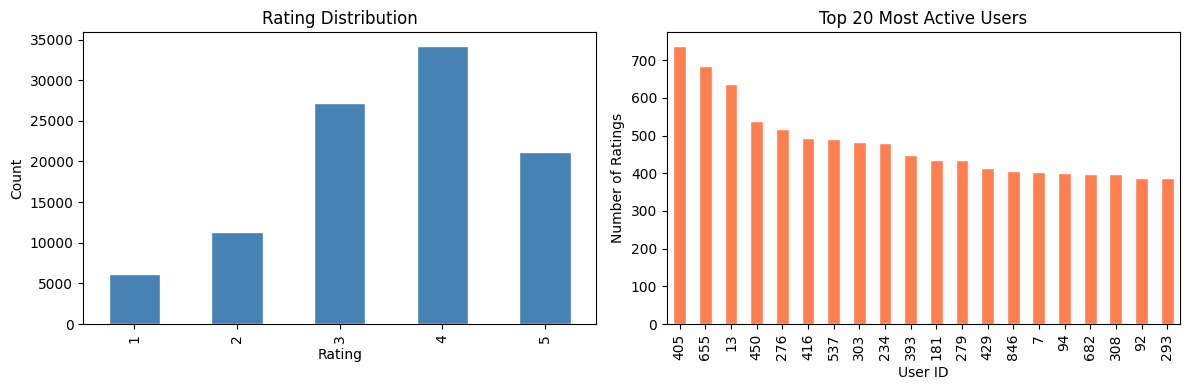

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Rating distribution
ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Plot 2: Ratings per user (top 20)
ratings.groupby('user_id').size().sort_values(ascending=False).head(20).plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('Top 20 Most Active Users')
axes[1].set_xlabel('User ID')
axes[1].set_ylabel('Number of Ratings')

plt.tight_layout()
plt.savefig('plots.png', dpi=150)
plt.show()